First 5 records:
          date     price  bedrooms  grade  has_basement  living_in_m2  \
0  2014-05-15  312000.0         2      2          True     138.42547   
1  2014-11-14  310000.0         2      2         False     105.90942   
2  2014-12-24  320000.0         2      2         False     117.98681   
3  2015-02-22  264500.0         2      3         False     151.43189   
4  2015-01-06  700000.0         3      2          True     341.88304   

   renovated  nice_view  perfect_condition  real_bathrooms  has_lavatory  \
0      False      False              False               2          True   
1      False      False              False               1          True   
2      False       True              False               1         False   
3      False      False              False               2          True   
4      False      False              False               3         False   

   single_floor  month  quartile_zone  
0         False      5              1  
1         Fa

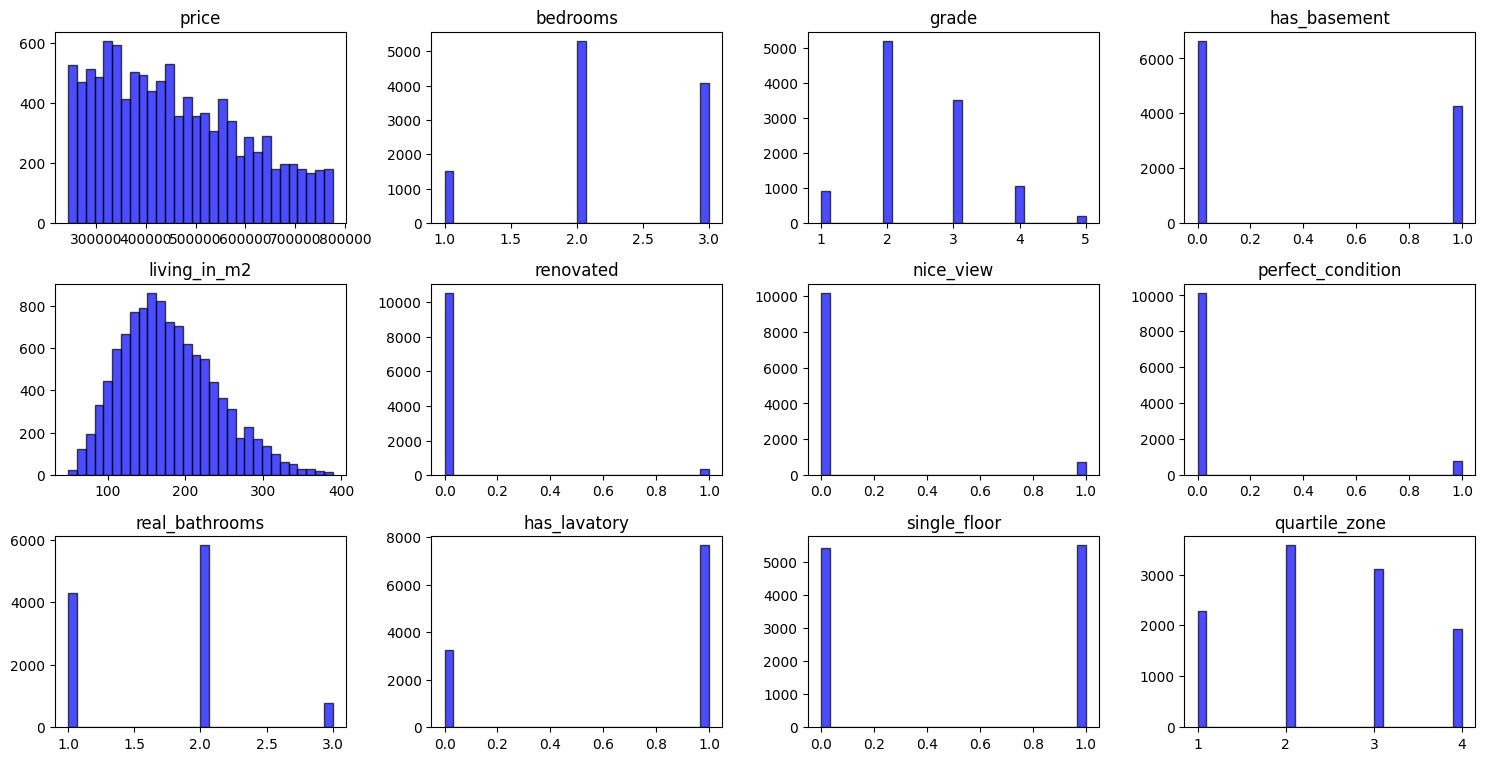


Final cleaned DataFrame info:
<class 'pandas.core.frame.DataFrame'>
Index: 10901 entries, 0 to 13602
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   price              10901 non-null  float64
 1   bedrooms           10901 non-null  int64  
 2   grade              10901 non-null  int64  
 3   has_basement       10901 non-null  int64  
 4   living_in_m2       10901 non-null  float64
 5   renovated          10901 non-null  int64  
 6   nice_view          10901 non-null  int64  
 7   perfect_condition  10901 non-null  int64  
 8   real_bathrooms     10901 non-null  int64  
 9   has_lavatory       10901 non-null  int64  
 10  single_floor       10901 non-null  int64  
 11  quartile_zone      10901 non-null  int64  
dtypes: float64(2), int64(10)
memory usage: 1.1 MB
None

First 5 records of cleaned DataFrame:
       price  bedrooms  grade  has_basement  living_in_m2  renovated  \
0  312000.0         2     

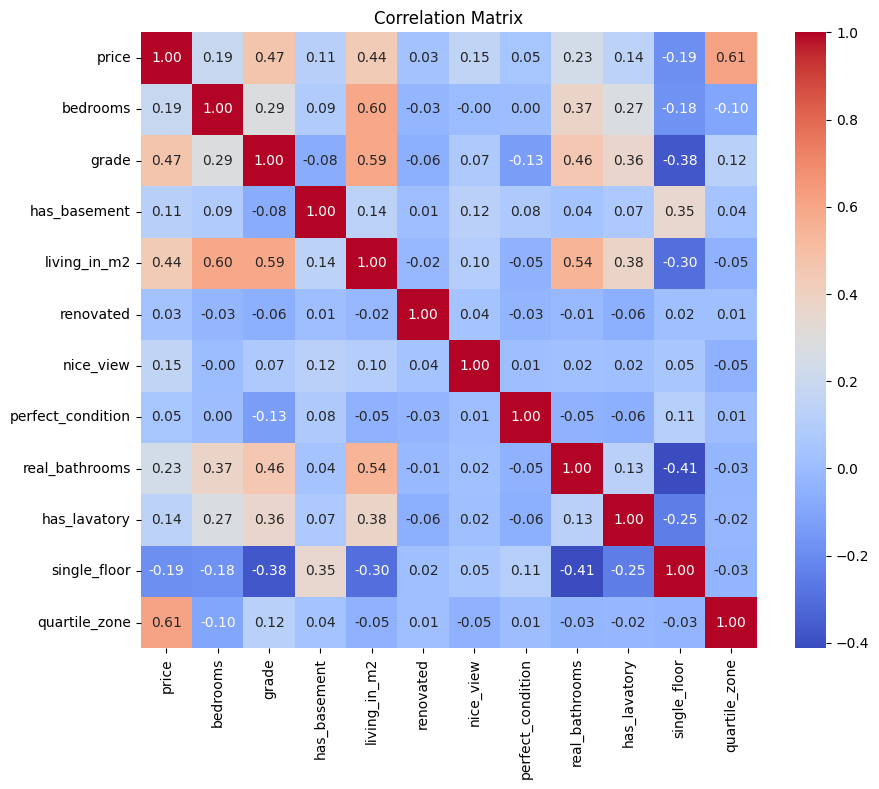

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import StandardScaler

# Set the path to the file you'd like to load
file_path = "df_train.csv"
file_path_test = "df_test.csv"

# Load the CSV with the correct encoding
df_train = pd.read_csv(file_path, encoding='utf-8', delimiter=',', decimal='.')
df_test = pd.read_csv(file_path_test, encoding='utf-8', delimiter=',', decimal='.')

print("First 5 records:\n", df_train.head())

print("\nEDA Summary:")
print(df_train.describe())

print("\nMissing values per column:\n", df_train.isnull().sum())

print("\nData types:\n", df_train.dtypes)

print("\nDataFrame shape after deletion:", df_train.shape)

print("\nColumn names:", df_train.columns.tolist())

print("\nDeleting rows with any missing values...")
df_train = df_train.dropna()
df_test = df_test.dropna()

print("\nDataFrame shape after deleting rows with missing values:", df_train.shape)

print("\nDeleting duplicate rows...")
df_train = df_train.drop_duplicates()
df_test = df_test.drop_duplicates()

print("\nDataFrame shape after deleting duplicate rows:", df_train.shape)

print("\nDeleting date columns...")
date_columns = [col for col in df_train.columns if 'date' in col.lower() or 'month' in col.lower()]
df_train = df_train.drop(columns=date_columns)
df_test = df_test.drop(columns=date_columns)

print("\nDataFrame shape after datetime deletion:", df_train.shape)

print("\nDeleting outliers. Values less than 10% or more than 90% quantiles for 'price' column...")
if 'price' in df_train.columns:
    lower_bound = df_train['price'].quantile(0.10)
    upper_bound = df_train['price'].quantile(0.90)
    df_train = df_train[(df_train['price'] >= lower_bound) & (df_train['price'] <= upper_bound)]
    print("\nDataFrame shape after deleting outliers in 'price':", df_train.shape)
    
if 'price' in df_test.columns:
    lower_bound_test = df_test['price'].quantile(0.10)
    upper_bound_test = df_test['price'].quantile(0.90)
    df_test = df_test[(df_test['price'] >= lower_bound_test) & (df_test['price'] <= upper_bound_test)]
    print("\nDataFrame shape after deleting outliers in 'price' for test set:", df_test.shape)
    
print("\nConverting boolean columns to integers...")
bool_cols = df_train.select_dtypes(include=['bool']).columns
df_train[bool_cols] = df_train[bool_cols].astype(int)
df_test[bool_cols] = df_test[bool_cols].astype(int)
    
print("\nPlotting hist plots for numeric columns...")
df_train.hist(bins=30, figsize=(15, 10), layout=(4, 4), color='blue', edgecolor='black', alpha=0.7, grid=False)
plt.tight_layout()
plt.show()

print("\nFinal cleaned DataFrame info:")
print(df_train.info())

print("\nFirst 5 records of cleaned DataFrame:\n", df_train.head())

print("\nData cleaning completed.")

print("\nMatrix of correlations:\n")
correlation_matrix = df_train.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation Matrix")
plt.show()

# Creando la red neuronal

c:\Users\TRENDINGPC\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenando Modelo 1 (1 característica)...
Pérdida Modelo 1 en Test: 0.8321011066436768


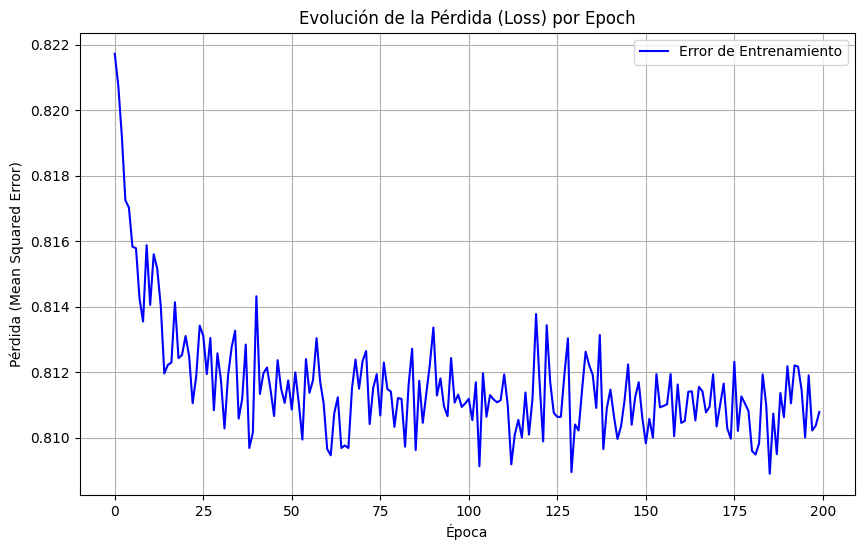

In [48]:
# --- FASE 1: UNA CARACTERÍSTICA ---
# Seleccionamos 'living_in_m2' por su alta correlación
feature_single = ['living_in_m2']
X_train_1 = df_train[feature_single]
y_train_1 = df_train['price']
X_test_1 = df_test[feature_single]
y_test_1 = df_test['price']

# Escalado
scaler_x1 = StandardScaler()
scaler_y1 = StandardScaler()

X_train_1_s = scaler_x1.fit_transform(X_train_1)
y_train_1_s = scaler_y1.fit_transform(y_train_1.values.reshape(-1, 1))
X_test_1_s = scaler_x1.transform(X_test_1)
y_test_1_s = scaler_y1.transform(y_test_1.values.reshape(-1, 1))

# Modelo Simple
model_1 = tf.keras.Sequential([
    # Etapa 1: Gran capacidad de captura
    tf.keras.layers.Dense(units=64, input_shape=[len(feature_single)], activation='relu'),
    # Etapa 2: Reducción y combinación
    tf.keras.layers.Dense(units=32, activation='relu'),
    # Etapa 3: Abstracción
    tf.keras.layers.Dense(units=16, activation='relu'),
    # Etapa 4: Refinamiento pre-salida
    tf.keras.layers.Dense(units=8, activation='relu'),
    # Salida
    tf.keras.layers.Dense(units=1)
])

model_1.compile(optimizer=tf.keras.optimizers.Adam(0.01), loss='mean_squared_error')
print('Entrenando Modelo 1 (1 característica)...')
history_1 = model_1.fit(X_train_1_s, y_train_1_s, epochs=200, verbose=0)

# Evaluación
loss_1 = model_1.evaluate(X_test_1_s, y_test_1_s, verbose=0)
print(f'Pérdida Modelo 1 en Test: {loss_1}')

# Plot del proceso de los epochs
plt.figure(figsize=(10, 6))
plt.plot(history_1.history['loss'], color='blue', label='Error de Entrenamiento')
plt.title('Evolución de la Pérdida (Loss) por Epoch')
plt.xlabel('Época')
plt.ylabel('Pérdida (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.show()

Entrenando Modelo 2 (Múltiples características)...


c:\Users\TRENDINGPC\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Pérdida Modelo 2 en Test: 0.3727821707725525


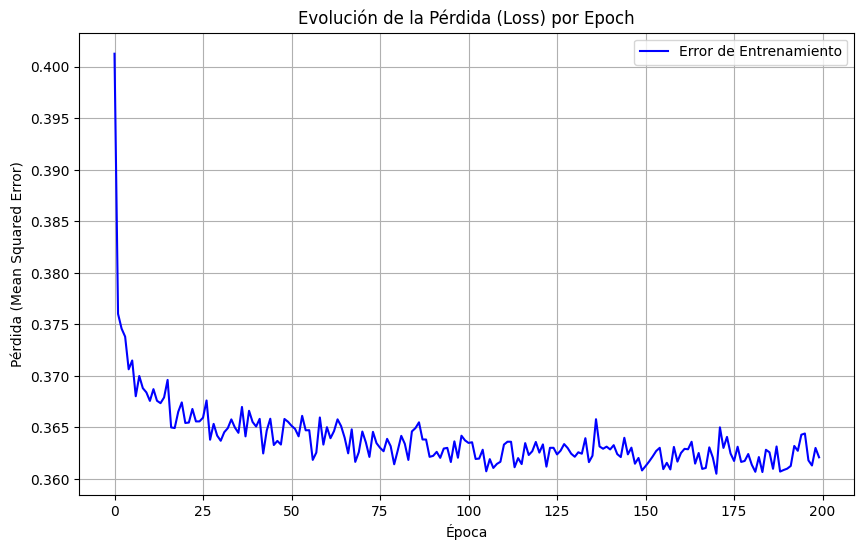

In [49]:
# --- FASE 2: MÚLTIPLES CARACTERÍSTICAS ---
features_multi = ['living_in_m2', 'grade', 'quartile_zone']
X_train_M = df_train[features_multi]
y_train_M = df_train['price']
X_test_M = df_test[features_multi]
y_test_M = df_test['price']

# Escalado
scaler_xM = StandardScaler()
scaler_yM = StandardScaler()

X_train_M_s = scaler_xM.fit_transform(X_train_M)
y_train_M_s = scaler_yM.fit_transform(y_train_M.values.reshape(-1, 1))
X_test_M_s = scaler_xM.transform(X_test_M)
y_test_M_s = scaler_yM.transform(y_test_M.values.reshape(-1, 1))

# Modelo Multivariable
model_M = tf.keras.Sequential([
    # Etapa 1: Gran capacidad de captura
    tf.keras.layers.Dense(units=64, input_shape=[len(features_multi)], activation='relu'),
    # Etapa 2: Reducción y combinación
    tf.keras.layers.Dense(units=32, activation='relu'),
    # Etapa 3: Abstracción
    tf.keras.layers.Dense(units=16, activation='relu'),
    # Etapa 4: Refinamiento pre-salida
    tf.keras.layers.Dense(units=8, activation='relu'),
    # Salida
    tf.keras.layers.Dense(units=1)
])

model_M.compile(optimizer=tf.keras.optimizers.Adam(0.01), loss='mean_squared_error')
print('Entrenando Modelo 2 (Múltiples características)...')
history_M = model_M.fit(X_train_M_s, y_train_M_s, epochs=200, verbose=0)

# Evaluación
loss_M = model_M.evaluate(X_test_M_s, y_test_M_s, verbose=0)
print(f'Pérdida Modelo 2 en Test: {loss_M}')

# Plot del proceso de los epochs
plt.figure(figsize=(10, 6))
plt.plot(history_M.history['loss'], color='blue', label='Error de Entrenamiento')
plt.title('Evolución de la Pérdida (Loss) por Epoch')
plt.xlabel('Época')
plt.ylabel('Pérdida (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.show()

169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 876us/step
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 911us/step


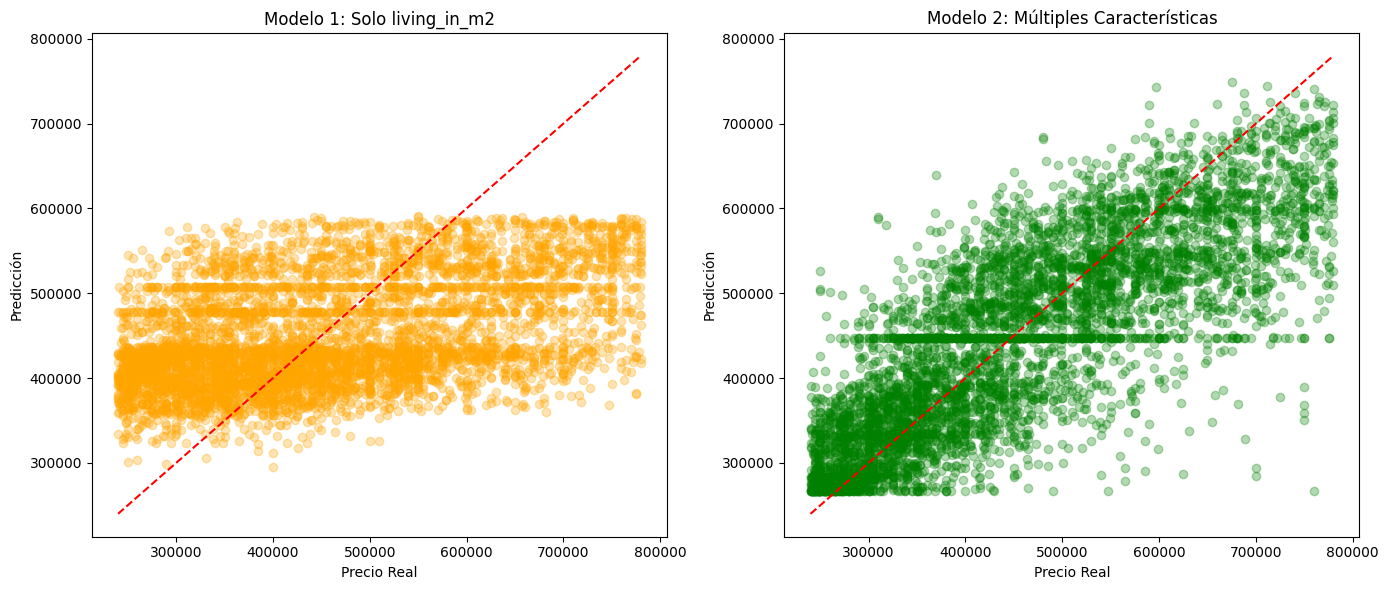


Comparativa de predicciones:
       Real  Pred_Simple   Pred_Multi
0  305000.0  354901.1250  302638.1250
1  498000.0  488151.8125  415938.3750
2  590000.0  544599.6875  554753.3125
3  775000.0  424660.0000  522583.4375
4  350000.0  369160.6250  379473.1875


In [50]:
# Predicciones
pred_1 = scaler_y1.inverse_transform(model_1.predict(X_test_1_s))
pred_M = scaler_yM.inverse_transform(model_M.predict(X_test_M_s))

# Visualización
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_test_1, pred_1, alpha=0.3, color='orange')
plt.plot([y_test_1.min(), y_test_1.max()], [y_test_1.min(), y_test_1.max()], 'r--')
plt.title('Modelo 1: Solo living_in_m2')
plt.xlabel('Precio Real')
plt.ylabel('Predicción')

plt.subplot(1, 2, 2)
plt.scatter(y_test_M, pred_M, alpha=0.3, color='green')
plt.plot([y_test_M.min(), y_test_M.max()], [y_test_M.min(), y_test_M.max()], 'r--')
plt.title('Modelo 2: Múltiples Características')
plt.xlabel('Precio Real')
plt.ylabel('Predicción')

plt.tight_layout()
plt.show()

# Tabla comparativa de los primeros 5 registros
comparativa = pd.DataFrame({
    'Real': y_test_1.values[:5],
    'Pred_Simple': pred_1.flatten()[:5],
    'Pred_Multi': pred_M.flatten()[:5]
})
print('\nComparativa de predicciones:')
print(comparativa)